# 4.2 - Regression Model: Training and Evaluation

## 1: Dependencies and Imports

In [1]:
# Instalar LightGBM directamente desde el notebook
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library
import os
import warnings

# Third-party
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

## 2: Load Data

In [3]:
# Path
input_file_path = '../data/Filtered.pkl'

if os.path.exists(input_file_path):
    df = pd.read_pickle(input_file_path)
    rows, cols = df.shape
    print(f"Dataset successfully loaded: {rows} rows and {cols} columns.")
else:
    print(f"Error: File not found at {input_file_path}")

# Quick preview of the loaded data
display(df.head(3))

Dataset successfully loaded: 114567 rows and 16 columns.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


## 3: Data Preparation

In [4]:
# Define the continuous regression target
y = df['actual_delivery_days']

# Extract metadata columns to keep them safe for later plotting/comparisons
meta_columns = ['estimated_delivery_margin_days']
meta_df = df[meta_columns]

# Define features to be excluded from training (No Data Leakage)
drop_columns = [
    'order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 
    'is_delayed', 'actual_delivery_days'
] + meta_columns

X = df.drop(columns=drop_columns, errors='ignore')

# Categorical Feature Definition
categorical_features = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for feature in categorical_features:
    if feature in X.columns:
        X[feature] = X[feature].astype('category')

print(f"Feature Selection Summary:")
print(f" - Predictor variables (X): {X.shape[1]}")
print(f" - Target variable (y): actual_delivery_days")
print(f" - Metadata saved (meta_df): {meta_df.shape[1]} columns")

Feature Selection Summary:
 - Predictor variables (X): 12
 - Target variable (y): actual_delivery_days
 - Metadata saved (meta_df): 1 columns


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   purchase_month                 114567 non-null  category
 1   purchase_day_of_week           114567 non-null  category
 2   product_weight_g               114567 non-null  float64 
 3   product_volume_cm3             114567 non-null  float64 
 4   product_category_name_english  114567 non-null  category
 5   customer_zip_code_prefix       114567 non-null  int64   
 6   seller_zip_code_prefix         114567 non-null  float64 
 7   is_same_state                  114567 non-null  category
 8   customer_state_num_pred        114567 non-null  category
 9   seller_state_num_pred          114567 non-null  category
 10  freight_value                  114567 non-null  float64 
 11  price                          114567 non-null  float64 
dtypes: category(6), float

In [6]:
# Initial split: Reserve 15% for the final Hold-out Test set
X_train_val, X_test, y_train_val, y_test, meta_train_val, meta_test = train_test_split(
    X, y, meta_df, test_size=0.15, random_state=42
)

# Second split: Partition the remaining 85% into Training and Validation sets
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_train_val, y_train_val, meta_train_val, test_size=0.15, random_state=42
)

print("Data partitioning complete:")
print(f" - Training Set:   {X_train.shape[0]} samples")
print(f" - Validation Set: {X_val.shape[0]} samples")
print(f" - Final Test Set: {X_test.shape[0]} samples")

Data partitioning complete:
 - Training Set:   82773 samples
 - Validation Set: 14608 samples
 - Final Test Set: 17186 samples


In [7]:
display(X_train)
display(y_train)

,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
44544,11,3,1800.0,32560.0,garden_tools,89230,15025.0,0,23,25,17.64,49.00
1118,7,4,900.0,11400.0,health_beauty,19830,80310.0,0,25,17,36.90,364.00
41933,12,6,200.0,1584.0,musical_instruments,14540,88056.0,0,25,23,16.00,177.90
118565,3,4,200.0,1056.0,health_beauty,30140,2350.0,0,10,25,18.80,559.99
13756,7,4,2050.0,15312.0,small_appliances,16400,21210.0,0,25,18,21.22,103.99
...,...,...,...,...,...,...,...,...,...,...,...,...
113325,7,5,250.0,2560.0,bed_bath_table,72250,14940.0,0,6,25,18.23,11.99
54540,7,4,1650.0,45000.0,sports_leisure,20031,87504.0,0,18,17,16.86,59.90
104182,8,5,150.0,1904.0,telephony,1046,13070.0,1,25,25,7.44,24.99
48740,12,4,600.0,8400.0,cool_stuff,35420,89254.0,0,10,23,17.92,25.00


44544     20.0
1118       9.0
41933     16.0
118565    11.0
13756     13.0
          ... 
113325     5.0
54540     17.0
104182     3.0
48740     12.0
55966     12.0
Name: actual_delivery_days, Length: 82773, dtype: float64

## 4: Model Definition

In [8]:
warnings.filterwarnings('ignore')

print("Initializing LightGBM model for REGRESSION...")

# Hyperparameter Definition
lgbm_regression_params = {
    'objective': 'regression',          
    'metric': 'rmse',                   
    'boosting_type': 'gbdt',
    
    'learning_rate': 0.01,
    'n_estimators': 10000,
    
    'num_leaves': 127,
    'max_depth': 12,
    'min_child_samples': 20,

    'reg_alpha': 0.1,
    'reg_lambda': 5.0,
    
    'subsample': 0.75,
    'colsample_bytree': 0.75,           
    'random_state': 42,
    'n_jobs': -1
}

# Model Instantiation
lgbm_regressor = lgb.LGBMRegressor(**lgbm_regression_params)

Initializing LightGBM model for REGRESSION...


In [9]:
# Model Fitting with Early Stopping
lgbm_regressor.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Training', 'Validation'],
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("\nRegression model training complete.")
print(f"Optimal number of iterations (trees): {lgbm_regressor.best_iteration_}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1679
[LightGBM] [Info] Number of data points in the train set: 82773, number of used features: 12
[LightGBM] [Info] Start training from score 11.999287
Training until validation scores don't improve for 200 rounds
[100]	Training's rmse: 7.89183	Validation's rmse: 7.98568
[200]	Training's rmse: 7.41632	Validation's rmse: 7.63585
[300]	Training's rmse: 7.18005	Validation's rmse: 7.5135
[400]	Training's rmse: 7.00527	Validation's rmse: 7.44557
[500]	Training's rmse: 6.86107	Validation's rmse: 7.39903
[600]	Training's rmse: 6.74126	Validation's rmse: 7.36234
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

## 5: Result Calculation

In [10]:
# Model Evaluation vs. Olist Legacy Baseline
y_pred = lgbm_regressor.predict(X_train)
y_olist_base = meta_train['estimated_delivery_margin_days'] # Olist's suggested time

# Model Metrics
mae_model = mean_absolute_error(y_train, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_train, y_pred))
r2_model = r2_score(y_train, y_pred)

# Olist Baseline Metrics
mae_olist = mean_absolute_error(y_train, y_olist_base)
rmse_olist = np.sqrt(mean_squared_error(y_train, y_olist_base))

print("Final Performance Comparison")
print("-" * 30)
print(f"Olist Legacy MAE:  {mae_olist:.2f} days")
print(f"AI Model MAE:      {mae_model:.2f} days")
print(f"Improvement:       {((mae_olist - mae_model) / mae_olist) * 100:.1f}%")
print("-" * 30)
print(f"Olist Legacy RMSE: {rmse_olist:.2f} days")
print(f"AI Model RMSE:     {rmse_model:.2f} days")
print(f"R-squared (R2):    {r2_model:.4f}")

# Sample Comparison
comparison_df = pd.DataFrame({
    'Actual': y_train, 
    'AI_Predicted': y_pred, 
    'Olist_Baseline': y_olist_base
}).head(10)

print("\nSample Predictions Comparison:")
print(comparison_df)

Final Performance Comparison
------------------------------
Olist Legacy MAE:  12.91 days
AI Model MAE:      2.15 days
Improvement:       83.3%
------------------------------
Olist Legacy RMSE: 15.29 days
AI Model RMSE:     3.51 days
R-squared (R2):    0.8601

Sample Predictions Comparison:
        Actual  AI_Predicted  Olist_Baseline
44544     20.0     19.654990              25
1118       9.0     10.291327              24
41933     16.0     17.408786              31
118565    11.0     12.272931              18
13756     13.0     11.142372              26
59190     22.0     23.106418              29
84362      7.0      6.764025              24
15868     11.0      9.732957              25
65393      7.0     10.051183              28
1025      12.0     10.426291              24


In [11]:
# Model Evaluation vs. Olist Legacy Baseline
y_pred = lgbm_regressor.predict(X_test)
y_olist_base = df.loc[X_test.index, 'estimated_delivery_margin_days']

# AI Model Metrics
mae_model = mean_absolute_error(y_test, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
r2_model = r2_score(y_test, y_pred)

# Olist Baseline Metrics
mae_olist = mean_absolute_error(y_test, y_olist_base)
rmse_olist = np.sqrt(mean_squared_error(y_test, y_olist_base))

print("Final Performance: AI Model vs. Olist Legacy")
print("-" * 45)
print(f"Olist Legacy MAE:  {mae_olist:.2f} days")
print(f"AI Model MAE:      {mae_model:.2f} days")
print(f"Error Reduction:   {((mae_olist - mae_model) / mae_olist) * 100:.1f}%")
print("-" * 45)
print(f"Olist Legacy RMSE: {rmse_olist:.2f} days")
print(f"AI Model RMSE:     {rmse_model:.2f} days")
print(f"AI Model R2 Score: {r2_model:.4f}")

# Sample Comparison Table
comparison_df = pd.DataFrame({
    'Actual_Days': y_test,
    'AI_Predicted': y_pred,
    'Olist_Estimate': y_olist_base
}).head(10)

print("\nSample Predictions Comparison:")
print(comparison_df)

Final Performance: AI Model vs. Olist Legacy
---------------------------------------------
Olist Legacy MAE:  12.92 days
AI Model MAE:      4.05 days
Error Reduction:   68.6%
---------------------------------------------
Olist Legacy RMSE: 15.43 days
AI Model RMSE:     7.08 days
AI Model R2 Score: 0.4534

Sample Predictions Comparison:
        Actual_Days  AI_Predicted  Olist_Estimate
106927          5.0      7.120460              22
69498           2.0      2.505674               2
100468         10.0     12.381126              19
105887         14.0      8.280198              26
52573          23.0     19.571015              23
103748          3.0      3.781405              15
69384           5.0      7.736143              11
94255           8.0     11.780142              22
105764          8.0      8.178640              28
55387           2.0      4.100728              18


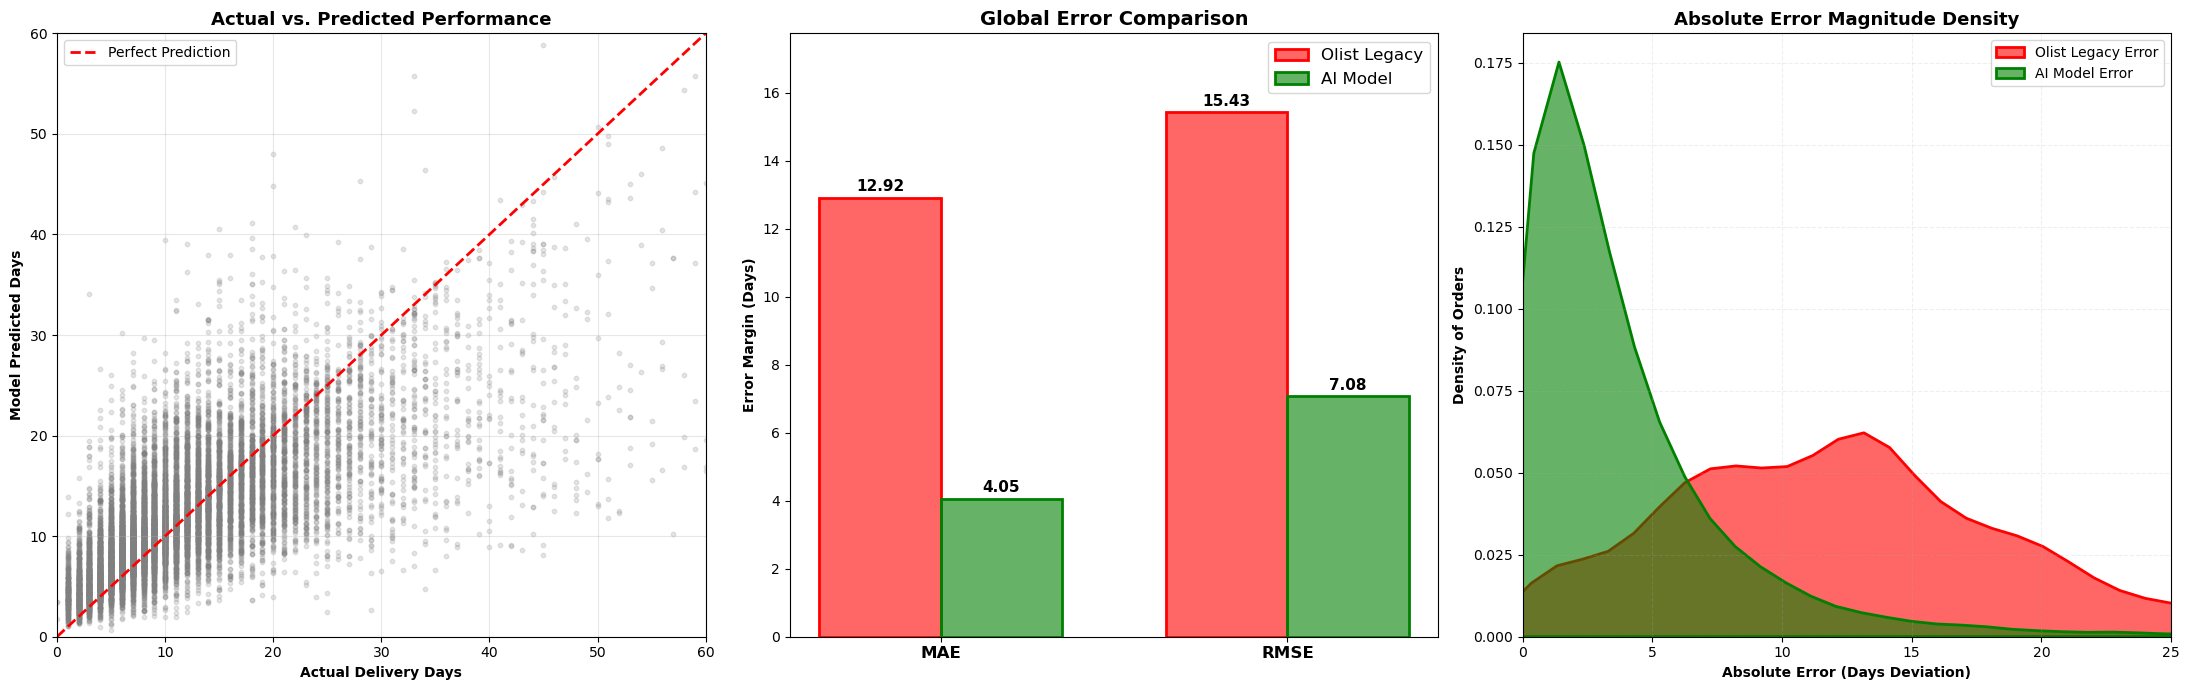

In [12]:
# Data Preparation & Metric Calculation
y_olist_pred = meta_test['estimated_delivery_margin_days']
mae_olist = mean_absolute_error(y_test, y_olist_pred)
rmse_olist = np.sqrt(mean_squared_error(y_test, y_olist_pred))
mae_ml = mean_absolute_error(y_test, y_pred)
rmse_ml = np.sqrt(mean_squared_error(y_test, y_pred))

# Integrated Visualization Dashboard
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# PLOT 1: Actual vs. Predicted Performance (Left)
axes[0].scatter(y_test, y_pred, alpha=0.2, color='gray', s=10)
axes[0].plot([0, 60], [0, 60], 'r--', lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Delivery Days", fontweight='bold')
axes[0].set_ylabel("Model Predicted Days", fontweight='bold')
axes[0].set_title("Actual vs. Predicted Performance", fontweight='bold', fontsize=13)
axes[0].set_xlim(0, 60)
axes[0].set_ylim(0, 60)
axes[0].legend()
axes[0].grid(alpha=0.3)

# PLOT 2: Executive Performance Metrics (Center)
metrics_labels = ['MAE', 'RMSE']
olist_values = [mae_olist, rmse_olist]
ml_values = [mae_ml, rmse_ml]

x_axis = np.arange(len(metrics_labels))
bar_width = 0.35

# Using RGBA for facecolor to keep fill transparent (0.6) while keeping edgecolor solid
axes[1].bar(x_axis - bar_width/2, olist_values, bar_width, label='Olist Legacy', 
            color=(1, 0, 0, 0.6), edgecolor='red', linewidth=2)
axes[1].bar(x_axis + bar_width/2, ml_values, bar_width, label='AI Model', 
            color=(0, 0.5, 0, 0.6), edgecolor='green', linewidth=2)

axes[1].set_ylabel('Error Margin (Days)', fontweight='bold')
axes[1].set_title('Global Error Comparison', fontweight='bold', fontsize=14)
axes[1].set_xticks(x_axis)
axes[1].set_xticklabels(metrics_labels, fontweight='bold', fontsize=12)
axes[1].legend(fontsize=12)

# Adjustment: Lowering the text labels and expanding the Y-axis limit for safety
max_val = max(max(olist_values), max(ml_values))
axes[1].set_ylim(0, max_val * 1.15) # Add 15% headrom at the top

for i, v in enumerate(olist_values):
    # Changed from v + 0.5 to v + 0.1
    axes[1].text(i - bar_width/2, v + 0.1, f"{v:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)
for i, v in enumerate(ml_values):
    # Changed from v + 0.5 to v + 0.1
    axes[1].text(i + bar_width/2, v + 0.1, f"{v:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

# PLOT 3: Error Magnitude Density (Right)
abs_error_olist = np.abs(y_test - y_olist_pred)
abs_error_ml = np.abs(y_test - y_pred)

# sns.kdeplot alpha applies to the fill; the line (contour) remains solid
sns.kdeplot(abs_error_olist, fill=True, color="red", label="Olist Legacy Error", alpha=0.6, ax=axes[2], linewidth=2)
sns.kdeplot(abs_error_ml, fill=True, color="green", label="AI Model Error", alpha=0.6, ax=axes[2], linewidth=2)

axes[2].set_title('Absolute Error Magnitude Density', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Absolute Error (Days Deviation)', fontweight='bold')
axes[2].set_ylabel('Density of Orders', fontweight='bold')
axes[2].set_xlim(0, 25) 
axes[2].legend()
axes[2].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

## 6: Advance Metrics and Performance

COMPARATIVE ERROR ANALYSIS: OLIST vs. AI MODEL
-------------------------------------------------------
Metric             | Olist Legacy    | AI Model
-------------------------------------------------------
MAE (Avg Error)    |        12.92 d |         4.05 d
Mean Bias (Skew)   |       -11.44 d |        -0.10 d
-------------------------------------------------------


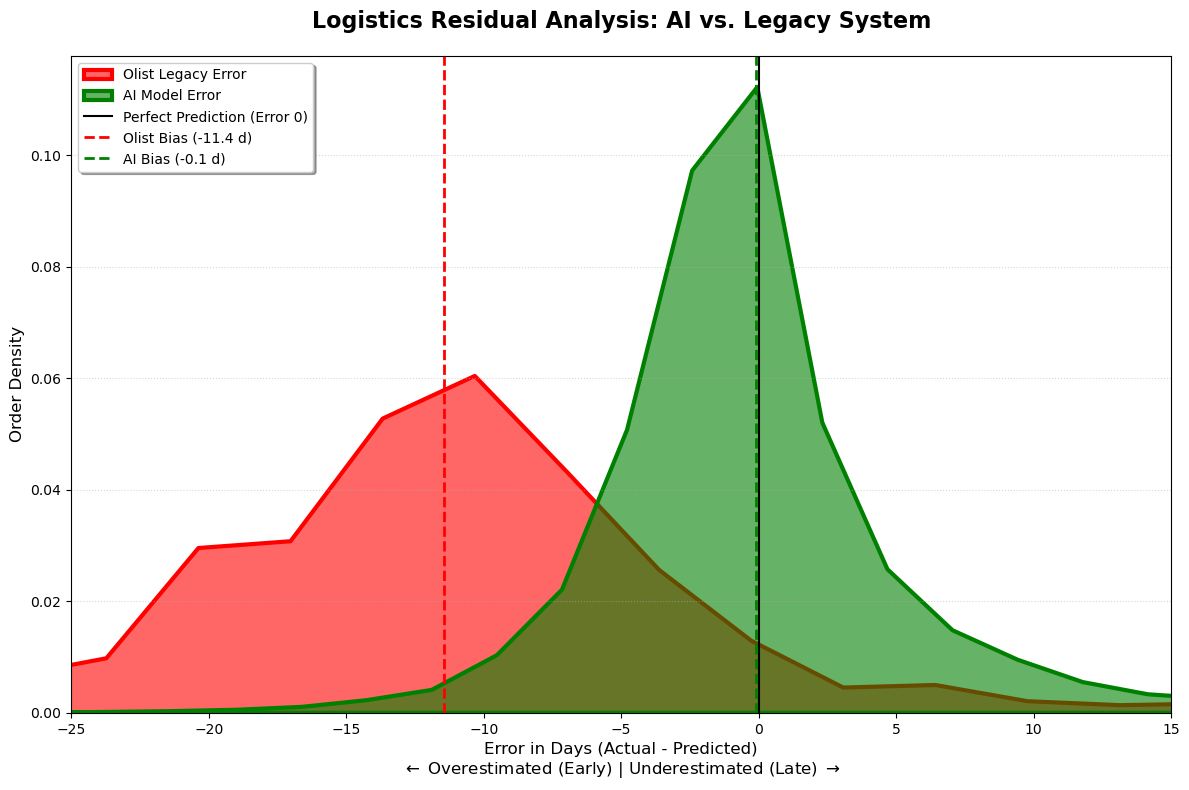

In [13]:
# --- 1. Alignment and Residual Calculation ---
ai_error = y_test - y_pred
legacy_estimation = df.loc[y_test.index, 'estimated_delivery_margin_days']
olist_error = y_test - legacy_estimation

# --- 2. Comparative Metrics Analysis (Cálculos e Impresión) ---
mae_ai = np.abs(ai_error).mean()
bias_ai = ai_error.mean()
mae_olist = np.abs(olist_error).mean()
bias_olist = olist_error.mean()

print("COMPARATIVE ERROR ANALYSIS: OLIST vs. AI MODEL")
print("-" * 55)
print(f"Metric             | Olist Legacy    | AI Model")
print("-" * 55)
print(f"MAE (Avg Error)    | {mae_olist:>12.2f} d | {mae_ai:>12.2f} d")
print(f"Mean Bias (Skew)   | {bias_olist:>12.2f} d | {bias_ai:>12.2f} d")
print("-" * 55)

# --- 3. Comparative Visualization ---
plt.figure(figsize=(12, 8))

# Olist Legacy: facecolor con alpha 0.6 y edgecolor sólido
sns.histplot(
    olist_error, bins=100, kde=False, 
    facecolor=(1, 0, 0, 0.6), edgecolor='red', 
    label='Olist Legacy Error', 
    element="poly",        
    stat="density",        
    linewidth=3
)

# AI Model Error: facecolor con alpha 0.6 y edgecolor sólido
sns.histplot(
    ai_error, bins=100, kde=False, 
    facecolor=(0, 0.5, 0, 0.6), edgecolor='green', 
    label='AI Model Error', 
    element="poly", 
    stat="density",
    linewidth=3
)

# --- 4. Líneas de Referencia y Bias ---
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5, label='Perfect Prediction (Error 0)', alpha=1)

plt.axvline(x=bias_olist, color='red', linestyle='--', linewidth=2, 
            label=f'Olist Bias ({bias_olist:.1f} d)')
plt.axvline(x=bias_ai, color='green', linestyle='--', linewidth=2, 
            label=f'AI Bias ({bias_ai:.1f} d)')

# --- 5. Estética y Formato ---
plt.title('Logistics Residual Analysis: AI vs. Legacy System', fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Error in Days (Actual - Predicted)\n' 
           r'$\leftarrow$ Overestimated (Early) | Underestimated (Late) $\rightarrow$', fontsize=12)

plt.ylabel('Order Density', fontsize=12)

plt.xlim(-25, 15) 
plt.legend(fontsize=10, loc='upper left', frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Enterprise Performance Comparison
----------------------------------------
Olist Legacy System  | MAE: 12.92 days | RMSE: 15.43 days
AI Prediction Model  | MAE: 4.05 days | RMSE: 7.08 days
Strategic Impact     | Error reduction of 68.6% achieved.
----------------------------------------


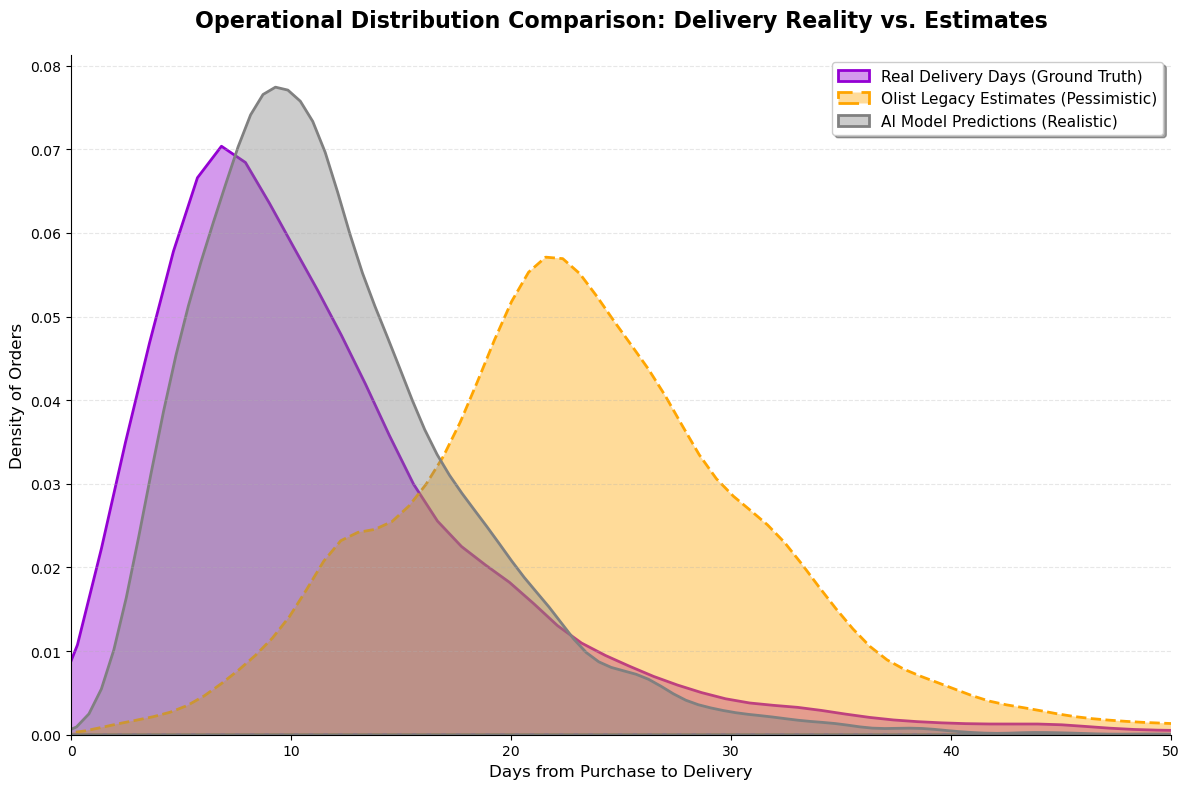

In [14]:
# Comparing Olist's Legacy Performance with the ML Model

# Extract the legacy Olist estimates from the Test set
y_olist_pred = meta_test['estimated_delivery_margin_days']

# 2. Calculate baseline metrics for Olist
mae_olist = mean_absolute_error(y_test, y_olist_pred)
rmse_olist = np.sqrt(mean_squared_error(y_test, y_olist_pred))

# 3. Calculate metrics for the ML Model (LightGBM)
mae_ml = mean_absolute_error(y_test, y_pred)
rmse_ml = np.sqrt(mean_squared_error(y_test, y_pred))

# 4. Numerical Executive Summary
print("Enterprise Performance Comparison")
print("-" * 40)
print(f"Olist Legacy System  | MAE: {mae_olist:.2f} days | RMSE: {rmse_olist:.2f} days")
print(f"AI Prediction Model  | MAE: {mae_ml:.2f} days | RMSE: {rmse_ml:.2f} days")
improvement = ((mae_olist - mae_ml) / mae_olist) * 100
print(f"Strategic Impact     | Error reduction of {improvement:.1f}% achieved.")
print("-" * 40)

# 5. Operational Distribution Alignment Analysis
# We initialize a single plot instead of a subplot grid
fig, ax = plt.subplots(figsize=(12, 8))

# Comparison of the Actual distribution vs. Legacy vs. AI
sns.kdeplot(y_test, fill=True, color="DarkViolet", label="Real Delivery Days (Ground Truth)", alpha=0.4, ax=ax, linewidth=2)
sns.kdeplot(y_olist_pred, fill=True, color="Orange", label="Olist Legacy Estimates (Pessimistic)", alpha=0.4, ax=ax, linewidth=2, linestyle='--')
sns.kdeplot(y_pred, fill=True, color="gray", label="AI Model Predictions (Realistic)", alpha=0.4, ax=ax, linewidth=2)

# Formatting for a single executive visualization
ax.set_title('Operational Distribution Comparison: Delivery Reality vs. Estimates', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Days from Purchase to Delivery', fontsize=12)
ax.set_ylabel('Density of Orders', fontsize=12)

# Strategic limits to focus on the core business operations
ax.set_xlim(0, 50)
ax.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Remove the top and right spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

## 7: Save Model

In [15]:
# Ensure the directory exists
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Define the model path; joblib is often more efficient for large NumPy arrays
model_file_path = os.path.join(models_dir, 'lgbm_regression_model.joblib')

# Serialize the model
joblib.dump(lgbm_regressor, model_file_path)

print(f"Model successfully saved to: {model_file_path}")

Model successfully saved to: ../models/lgbm_regression_model.joblib
